# Gaussian Naive Bayes

# Descripción

Gaussian Naive Bayes (GNB) es un algoritmo de clasificación probabilística basado en el Teorema de Bayes. Pertenece a la familia de los clasificadores Naive Bayes y asume que las características son condicionalmente independientes entre sí dada la clase. Su principal característica es que modela las variables de entrada continuas mediante una distribución normal (gaussiana), estimando para cada clase la media y la varianza de cada atributo.

Durante la fase de predicción, el algoritmo calcula la probabilidad posterior de cada clase utilizando las probabilidades a priori y la función de densidad gaussiana. Finalmente, asigna la observación a la clase con la mayor probabilidad posterior (Maximum A Posteriori, MAP).

Gaussian Naive Bayes es ampliamente utilizado en problemas de clasificación supervisada debido a su simplicidad, rapidez de entrenamiento, bajo costo computacional y buen desempeño en conjuntos de datos de tamaño pequeño y mediano.

# BIBTEX y Referencias

1. John, G. H., & Langley, P. (1995). Estimating Continuous Distributions in Bayesian Classifiers. Proceedings of the Eleventh Conference on Uncertainty in Artificial Intelligence (UAI), 338–345.

2. Duda, R. O., Hart, P. E., & Stork, D. G. (2001). Pattern Classification (2nd ed.). John Wiley & Sons.

3. Murphy, K. P. (2012). Machine Learning: A Probabilistic Perspective. MIT Press.




# Tipo de Modelo

• **Método de Aprendizaje:** Aprendizaje Supervisado.

• **Tipo por Parámetros:** Modelo Paramétrico.

• **Tipo de Datos de Aprendizaje:** Variables numéricas continuas con etiquetas de clase.

• **Resultado del Entrenamiento:** Modelo probabilístico basado en la estimación de parámetros gaussianos (media, varianza y probabilidades a priori) para cada clase.

# Alg. Entrenamiento

**Gaussian Naive Bayes**

Durante el entrenamiento el algoritmo realiza las siguientes etapas:

1. Calcula la probabilidad a priori de cada clase.
2. Estima la media (μ) de cada característica para cada clase.
3. Estima la varianza (σ²) de cada característica para cada clase.
4. Modela cada característica mediante una distribución normal (gaussiana).
5. Almacena estos parámetros para calcular la probabilidad posterior durante la clasificación de nuevas observaciones.

# Supuestos y Restricciones

## Supuestos

• Las características son condicionalmente independientes dada la clase.

• Cada característica continua sigue una distribución normal (gaussiana).

• Las muestras de entrenamiento representan adecuadamente la distribución de los datos.

• Los parámetros estimados (media y varianza) describen correctamente el comportamiento de cada clase.

## Restricciones

• El supuesto de independencia entre variables rara vez se cumple completamente en problemas reales.

• El rendimiento disminuye cuando las características no presentan una distribución aproximadamente normal.

• Es sensible a valores atípicos (outliers), ya que afectan la estimación de la media y la varianza.

• Puede presentar menor precisión que modelos más complejos cuando existen fuertes correlaciones entre las variables.

# Ventajas

• Entrenamiento muy rápido.

• Baja complejidad computacional.

• Requiere pocos datos para estimar sus parámetros.

• Fácil de implementar e interpretar.

• Funciona adecuadamente en conjuntos de datos pequeños y medianos.

• Es ampliamente utilizado como modelo base (baseline) en problemas de clasificación.

# Desventajas

• Supone independencia entre las características.

• Requiere que las variables continuas sigan aproximadamente una distribución normal.

• Su desempeño disminuye cuando las variables están altamente correlacionadas.

• Puede ser sensible a valores extremos.

• Generalmente obtiene menor precisión que modelos más complejos cuando los datos presentan relaciones no lineales.

# Implementación en Python de Gaussian Naive Bayes

En esta sección se implementa el algoritmo Gaussian Naive Bayes utilizando la biblioteca Scikit-Learn.

Para evaluar el funcionamiento del modelo se utilizará el conjunto de datos Iris, un conjunto de datos clásico en Machine Learning para problemas de clasificación.

El objetivo es clasificar tres especies de flores utilizando sus características físicas:

- Longitud del sépalo.
- Ancho del sépalo.
- Longitud del pétalo.
- Ancho del pétalo.

# Importación de Librerías

Se importan las herramientas necesarias para:

- Manipulación de datos.
- Entrenamiento del modelo.
- Evaluación del clasificador.
- Visualización de resultados.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Carga del Dataset Iris

El conjunto de datos Iris contiene 150 muestras de flores pertenecientes a tres clases diferentes.

Cada muestra posee cuatro características numéricas que serán utilizadas como variables de entrada para el modelo Gaussian Naive Bayes.

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Características utilizadas:")
print(iris.feature_names)

print("\nClases:")
print(iris.target_names)

Características utilizadas:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Clases:
['setosa' 'versicolor' 'virginica']


# Distribución de las Clases

Antes de entrenar el modelo se analiza la cantidad de muestras disponibles para cada clase.

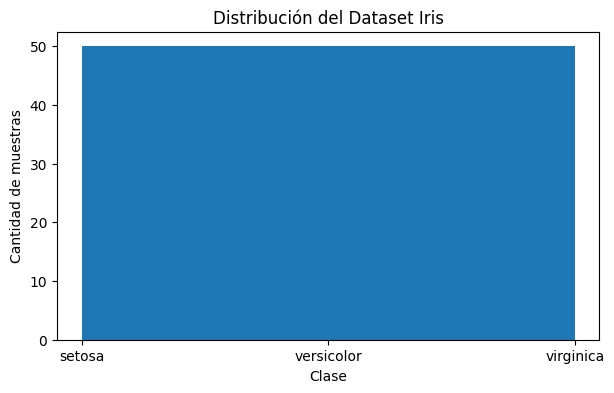

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(y, bins=3)

plt.xticks(
    [0,1,2],
    iris.target_names
)

plt.xlabel("Clase")
plt.ylabel("Cantidad de muestras")

plt.title("Distribución del Dataset Iris")

plt.show()

# División del Dataset

Para evaluar el modelo correctamente, el conjunto de datos se divide en dos grupos:

- Datos de entrenamiento: utilizados para que el modelo aprenda los parámetros estadísticos.
- Datos de prueba: utilizados para evaluar la capacidad de generalización del modelo sobre datos no observados.

Se utilizará una proporción del 70% para entrenamiento y 30% para prueba.

In [ ]:
# División de datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (105, 4)
Datos de prueba: (45, 4)


# Entrenamiento del Modelo Gaussian Naive Bayes

En esta etapa se crea el clasificador Gaussian Naive Bayes y se ajustan sus parámetros utilizando los datos de entrenamiento.

Durante este proceso el modelo estima:

- Probabilidades a priori de cada clase.
- Media de cada característica.
- Varianza de cada característica.

Estos parámetros serán utilizados posteriormente para clasificar nuevas observaciones.

In [ ]:
# Crear y entrenar el modelo

modelo = GaussianNB()

modelo.fit(X_train, y_train)

print("Modelo Gaussian Naive Bayes entrenado correctamente.")

Modelo Gaussian Naive Bayes entrenado correctamente.


# Predicción del Modelo

Después del entrenamiento, el modelo es utilizado para predecir la clase correspondiente a las muestras del conjunto de prueba.

In [ ]:
# Predicciones

y_pred = modelo.predict(X_test)

print("Predicciones realizadas:")
print(y_pred)

Predicciones realizadas:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


# Evaluación del Modelo

Para medir el desempeño del clasificador se utilizan diferentes métricas:

- Accuracy: proporción de predicciones correctas.
- Precision: mide la exactitud de las predicciones positivas.
- Recall: mide la capacidad de identificar correctamente las clases.
- F1-score: combinación entre Precision y Recall.

Estas métricas permiten analizar la calidad del modelo de clasificación.

In [ ]:
# Cálculo de métricas

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.9777777777777777
Precision: 0.9793650793650793
Recall: 0.9777777777777777
F1-Score: 0.9777448559670782


# Matriz de Confusión

La matriz de confusión permite observar la cantidad de predicciones correctas e incorrectas realizadas por el modelo para cada clase.

La diagonal principal representa las clasificaciones correctas, mientras que los valores fuera de la diagonal representan errores de clasificación.

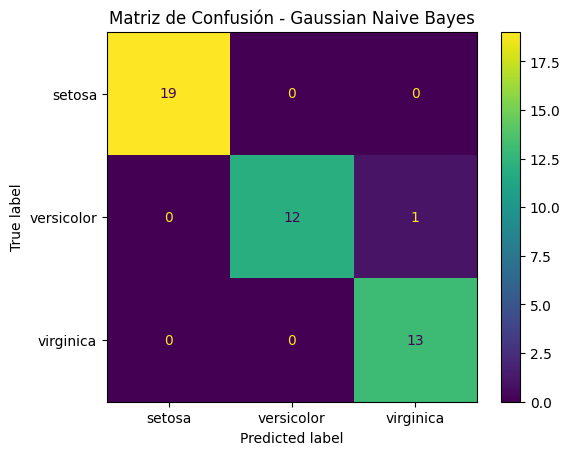

In [ ]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Matriz de Confusión - Gaussian Naive Bayes")

plt.show()

# Reporte de Clasificación

Además de las métricas generales, se presenta un reporte detallado por clase, donde se analiza el comportamiento del modelo para cada categoría del conjunto de datos.

Se muestran:

- Precision.
- Recall.
- F1-score.
- Cantidad de muestras evaluadas.

In [ ]:
# Reporte de clasificación por clase

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



# Visualización de las Características del Dataset

Para comprender mejor la distribución de los datos, se realiza una visualización utilizando dos características del conjunto Iris.

Se representan:

- Longitud del pétalo.
- Ancho del pétalo.

Cada color representa una clase diferente de flor.

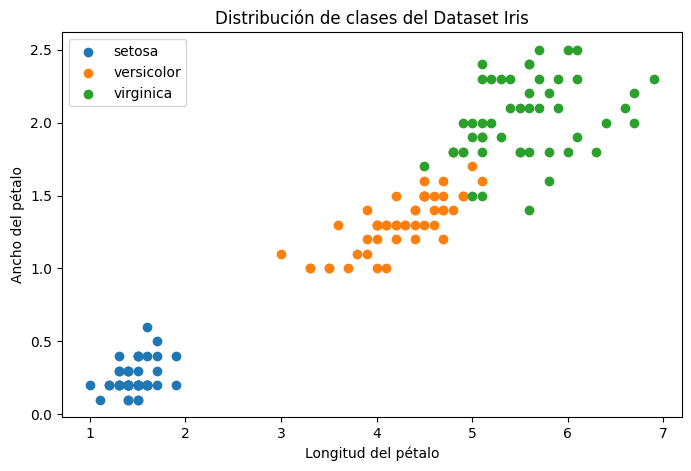

In [ ]:
# Visualización de datos Iris

plt.figure(figsize=(8,5))

for clase in range(3):
    plt.scatter(
        X[y == clase, 2],
        X[y == clase, 3],
        label=iris.target_names[clase]
    )

plt.xlabel("Longitud del pétalo")
plt.ylabel("Ancho del pétalo")

plt.title("Distribución de clases del Dataset Iris")

plt.legend()

plt.show()

# Predicción de una Nueva Observación

Finalmente, se prueba el modelo con una nueva muestra que no pertenece al conjunto de entrenamiento.

El modelo calcula la probabilidad de pertenencia a cada clase y selecciona aquella con mayor probabilidad posterior.

In [ ]:
# Nueva observación

nueva_muestra = np.array([
    [5.1, 3.5, 1.4, 0.2]
])


prediccion = modelo.predict(nueva_muestra)


print(
    "Clase predicha:",
    iris.target_names[prediccion][0]
)

Clase predicha: setosa


# Análisis de Resultados

El modelo Gaussian Naive Bayes fue entrenado utilizando el conjunto de datos Iris y evaluado mediante diferentes métricas de clasificación.

Los resultados permiten observar que el algoritmo presenta un buen desempeño para este problema debido a que las características del dataset presentan una distribución adecuada para el modelo probabilístico.

La matriz de confusión permite identificar que la mayoría de las muestras fueron clasificadas correctamente, con pocos errores entre clases.

Sin embargo, el rendimiento del algoritmo depende de que se cumplan sus principales supuestos, especialmente la independencia entre características y la aproximación de las variables continuas mediante distribuciones gaussianas.

# Conclusión

Gaussian Naive Bayes es un algoritmo eficiente para problemas de clasificación supervisada con variables continuas. Su principal ventaja es la rapidez de entrenamiento y su bajo costo computacional debido a la estimación de un número reducido de parámetros.

Aunque sus supuestos de independencia condicional y distribución gaussiana pueden limitar su desempeño en ciertos escenarios, continúa siendo una técnica importante dentro del aprendizaje automático debido a su interpretación probabilística y utilidad como modelo base de comparación.